In [ ]:
# Step 14: Set up forecasting notebook and load processed daily demand data

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define project directories
current_dir = Path.cwd()
project_dir = current_dir.parent

processed_dir = project_dir / "data" / "processed"
figures_dir = project_dir / "outputs" / "figures"
tables_dir = project_dir / "outputs" / "tables"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Load the processed daily demand dataset
processed_file_path = processed_dir / "daily_demand_FOODS_3_586_TX_2.csv"

daily_demand = pd.read_csv(processed_file_path)

# Convert date column to datetime format
daily_demand["date"] = pd.to_datetime(daily_demand["date"])

# Sort data by date
daily_demand = daily_demand.sort_values("date").reset_index(drop=True)

print("Step 14 completed: Forecasting notebook setup finished.")

print("\nCurrent notebook directory:")
print(current_dir)

print("\nProject directory:")
print(project_dir)

print("\nProcessed data path:")
print(processed_file_path)

print("\nDaily demand shape:")
print(daily_demand.shape)

print("\nDate range:")
print(daily_demand["date"].min(), "to", daily_demand["date"].max())

print("\nKey columns:")
print(daily_demand.columns.tolist())

print("\nDemand and price summary:")
display(daily_demand[["demand", "sell_price"]].describe())

Step 14 completed: Forecasting notebook setup finished.

Current notebook directory:
/Users/mac/Desktop/portfolio1_demand_inventory/notebooks

Project directory:
/Users/mac/Desktop/portfolio1_demand_inventory

Processed data path:
/Users/mac/Desktop/portfolio1_demand_inventory/data/processed/daily_demand_FOODS_3_586_TX_2.csv

Daily demand shape:
(1941, 16)

Date range:
2011-01-29 00:00:00 to 2016-05-22 00:00:00

Key columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'demand', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'sell_price', 'sales_revenue']

Demand and price summary:


,demand,sell_price
count,1941.000000,1941.000000
mean,100.525502,1.594529
std,30.824629,0.072191
min,0.000000,1.480000
25%,79.000000,1.580000
50%,97.000000,1.580000
75%,118.000000,1.680000
max,237.000000,1.680000


In [ ]:
# Step 15: Create a time-based train-test split

# Define the forecasting horizon
forecast_horizon = 56

# Split the dataset chronologically
train_data = daily_demand.iloc[:-forecast_horizon].copy()
test_data = daily_demand.iloc[-forecast_horizon:].copy()

# Create a summary table for the train-test split
split_summary = pd.DataFrame({
    "dataset": ["Train", "Test"],
    "number_of_days": [len(train_data), len(test_data)],
    "start_date": [train_data["date"].min(), test_data["date"].min()],
    "end_date": [train_data["date"].max(), test_data["date"].max()],
    "mean_demand": [
        train_data["demand"].mean(),
        test_data["demand"].mean()
    ],
    "min_demand": [
        train_data["demand"].min(),
        test_data["demand"].min()
    ],
    "max_demand": [
        train_data["demand"].max(),
        test_data["demand"].max()
    ]
})

print("Step 15 completed: Time-based train-test split created.")

print("\nForecast horizon:")
print(forecast_horizon, "days")

print("\nTrain-test split summary:")
display(split_summary)

print("\nValidation checks:")
print("Total observations:", len(train_data) + len(test_data))
print("Original observations:", len(daily_demand))
print("Training end date:", train_data["date"].max())
print("Testing start date:", test_data["date"].min())
print("Date gap between train and test:", (test_data["date"].min() - train_data["date"].max()).days)

Step 15 completed: Time-based train-test split created.

Forecast horizon:
56 days

Train-test split summary:


,dataset,number_of_days,start_date,end_date,mean_demand,min_demand,max_demand
0,Train,1885,2011-01-29,2016-03-27,101.170822,0,237
1,Test,56,2016-03-28,2016-05-22,78.803571,36,119



Validation checks:
Total observations: 1941
Original observations: 1941
Training end date: 2016-03-27 00:00:00
Testing start date: 2016-03-28 00:00:00
Date gap between train and test: 1


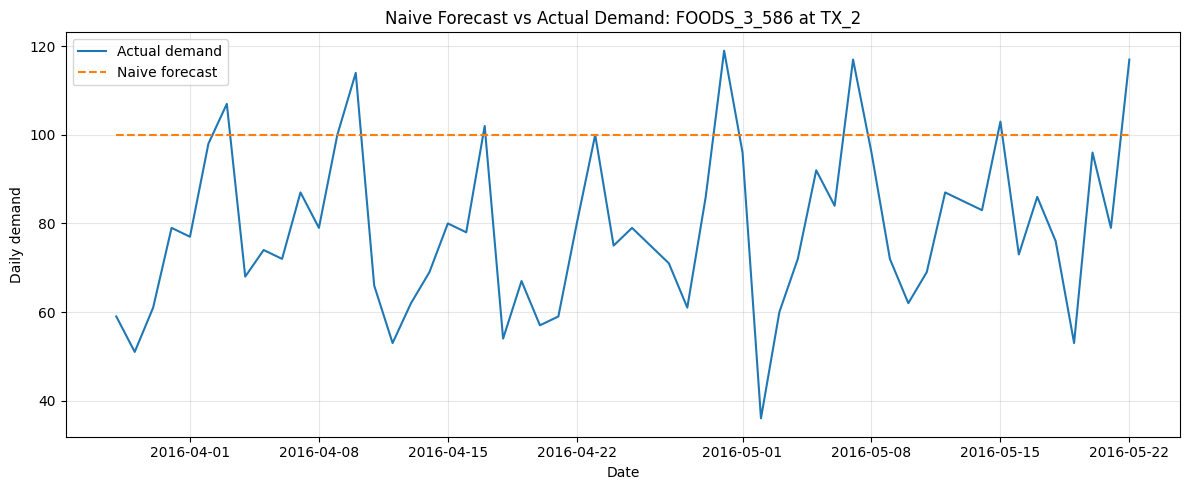

Step 16 completed: Naive baseline forecast created.

Naive forecast value:
100

Naive forecast metrics:


,model,forecast_horizon_days,forecast_value,MAE,RMSE,MAPE_percent
0,Naive forecast,56,100,24.017857,27.959473,36.776469



Forecast results preview:


,date,actual_demand,naive_forecast
1885,2016-03-28,59,100
1886,2016-03-29,51,100
1887,2016-03-30,61,100
1888,2016-03-31,79,100
1889,2016-04-01,77,100
1890,2016-04-02,98,100
1891,2016-04-03,107,100
1892,2016-04-04,68,100
1893,2016-04-05,74,100
1894,2016-04-06,72,100



Tables saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/naive_forecast_results_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/naive_forecast_metrics_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/naive_forecast_vs_actual_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/naive_forecast_vs_actual_FOODS_3_586_TX_2.pdf


In [ ]:
# Step 16: Build a naive baseline forecast

# Create naive forecast using the last observed demand in the training data
naive_forecast_value = train_data["demand"].iloc[-1]

# Create forecast results dataframe
forecast_results = test_data[["date", "demand"]].copy()
forecast_results = forecast_results.rename(columns={"demand": "actual_demand"})
forecast_results["naive_forecast"] = naive_forecast_value

# Define forecast evaluation metrics
actual = forecast_results["actual_demand"]
predicted = forecast_results["naive_forecast"]

mae = np.mean(np.abs(actual - predicted))
rmse = np.sqrt(np.mean((actual - predicted) ** 2))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

# Create metrics table
naive_metrics = pd.DataFrame({
    "model": ["Naive forecast"],
    "forecast_horizon_days": [forecast_horizon],
    "forecast_value": [naive_forecast_value],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE_percent": [mape]
})

# Save forecast results and metrics
naive_forecast_results_path = tables_dir / "naive_forecast_results_FOODS_3_586_TX_2.csv"
naive_metrics_path = tables_dir / "naive_forecast_metrics_FOODS_3_586_TX_2.csv"

forecast_results.to_csv(naive_forecast_results_path, index=False)
naive_metrics.to_csv(naive_metrics_path, index=False)

# Plot actual demand vs naive forecast
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_results["date"],
    forecast_results["actual_demand"],
    linewidth=1.5,
    label="Actual demand"
)

plt.plot(
    forecast_results["date"],
    forecast_results["naive_forecast"],
    linewidth=1.5,
    linestyle="--",
    label="Naive forecast"
)

plt.title("Naive Forecast vs Actual Demand: FOODS_3_586 at TX_2")
plt.xlabel("Date")
plt.ylabel("Daily demand")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

naive_forecast_png_path = figures_dir / "naive_forecast_vs_actual_FOODS_3_586_TX_2.png"
naive_forecast_pdf_path = figures_dir / "naive_forecast_vs_actual_FOODS_3_586_TX_2.pdf"

plt.savefig(naive_forecast_png_path, dpi=300, bbox_inches="tight")
plt.savefig(naive_forecast_pdf_path, bbox_inches="tight")

plt.show()

print("Step 16 completed: Naive baseline forecast created.")

print("\nNaive forecast value:")
print(naive_forecast_value)

print("\nNaive forecast metrics:")
display(naive_metrics)

print("\nForecast results preview:")
display(forecast_results.head(10))

print("\nTables saved to:")
print(naive_forecast_results_path)
print(naive_metrics_path)

print("\nFigures saved to:")
print(naive_forecast_png_path)
print(naive_forecast_pdf_path)

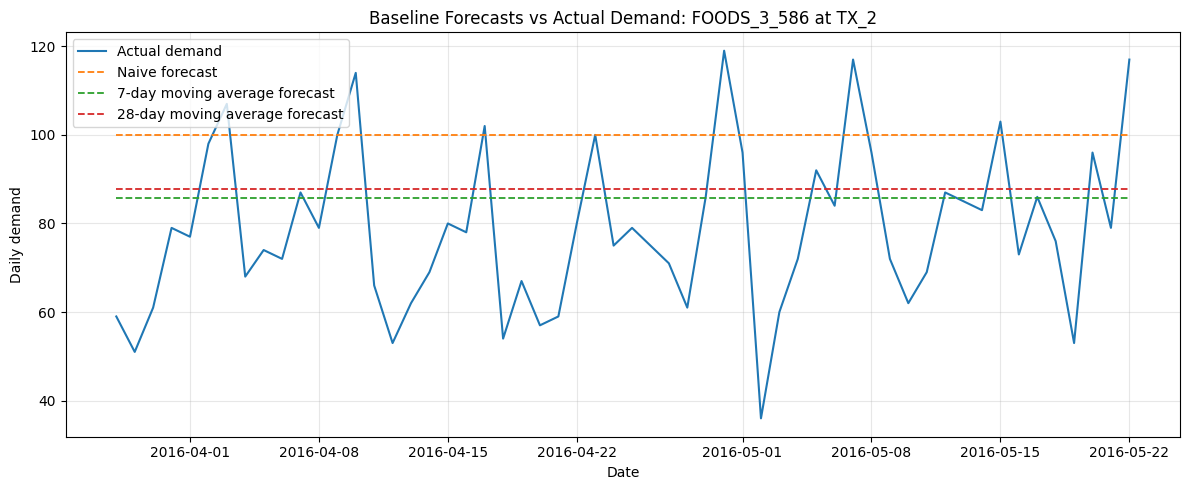

Step 17 completed: Moving average baseline forecasts created.

Moving average forecast values:
7-day moving average forecast value: 85.86
28-day moving average forecast value: 87.71

Baseline forecast metrics:


,model,forecast_horizon_days,forecast_value,MAE,RMSE,MAPE_percent
0,Naive forecast,56,100.000000,24.017857,27.959473,36.776469
1,7-day moving average forecast,56,85.857143,16.252551,19.549845,23.896987
2,28-day moving average forecast,56,87.714286,17.089286,20.293950,25.387442



Updated forecast results preview:


,date,actual_demand,naive_forecast,ma_7_forecast,ma_28_forecast
1885,2016-03-28,59,100,85.857143,87.714286
1886,2016-03-29,51,100,85.857143,87.714286
1887,2016-03-30,61,100,85.857143,87.714286
1888,2016-03-31,79,100,85.857143,87.714286
1889,2016-04-01,77,100,85.857143,87.714286
1890,2016-04-02,98,100,85.857143,87.714286
1891,2016-04-03,107,100,85.857143,87.714286
1892,2016-04-04,68,100,85.857143,87.714286
1893,2016-04-05,74,100,85.857143,87.714286
1894,2016-04-06,72,100,85.857143,87.714286



Tables saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/baseline_forecast_results_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/baseline_forecast_metrics_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/baseline_forecasts_vs_actual_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/baseline_forecasts_vs_actual_FOODS_3_586_TX_2.pdf


In [ ]:
# Step 17: Build moving average baseline forecasts

# Calculate moving average forecast values from the training data
ma_7_forecast_value = train_data["demand"].tail(7).mean()
ma_28_forecast_value = train_data["demand"].tail(28).mean()

# Add moving average forecasts to the existing forecast results dataframe
forecast_results["ma_7_forecast"] = ma_7_forecast_value
forecast_results["ma_28_forecast"] = ma_28_forecast_value

# Define a reusable forecast evaluation function
def calculate_forecast_metrics(actual_values, predicted_values, model_name, forecast_horizon_days):
    mae = np.mean(np.abs(actual_values - predicted_values))
    rmse = np.sqrt(np.mean((actual_values - predicted_values) ** 2))
    mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100
    
    return {
        "model": model_name,
        "forecast_horizon_days": forecast_horizon_days,
        "forecast_value": predicted_values.iloc[0],
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_percent": mape
    }

# Calculate metrics for moving average forecasts
actual = forecast_results["actual_demand"]

ma_7_metrics = calculate_forecast_metrics(
    actual_values=actual,
    predicted_values=forecast_results["ma_7_forecast"],
    model_name="7-day moving average forecast",
    forecast_horizon_days=forecast_horizon
)

ma_28_metrics = calculate_forecast_metrics(
    actual_values=actual,
    predicted_values=forecast_results["ma_28_forecast"],
    model_name="28-day moving average forecast",
    forecast_horizon_days=forecast_horizon
)

# Combine naive and moving average metrics
baseline_metrics = pd.concat(
    [
        naive_metrics,
        pd.DataFrame([ma_7_metrics, ma_28_metrics])
    ],
    ignore_index=True
)

# Save updated forecast results and baseline metrics
baseline_forecast_results_path = tables_dir / "baseline_forecast_results_FOODS_3_586_TX_2.csv"
baseline_metrics_path = tables_dir / "baseline_forecast_metrics_FOODS_3_586_TX_2.csv"

forecast_results.to_csv(baseline_forecast_results_path, index=False)
baseline_metrics.to_csv(baseline_metrics_path, index=False)


# ============================================================
# Plot: Actual demand vs baseline forecasts
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    forecast_results["date"],
    forecast_results["actual_demand"],
    linewidth=1.5,
    label="Actual demand"
)

plt.plot(
    forecast_results["date"],
    forecast_results["naive_forecast"],
    linewidth=1.3,
    linestyle="--",
    label="Naive forecast"
)

plt.plot(
    forecast_results["date"],
    forecast_results["ma_7_forecast"],
    linewidth=1.3,
    linestyle="--",
    label="7-day moving average forecast"
)

plt.plot(
    forecast_results["date"],
    forecast_results["ma_28_forecast"],
    linewidth=1.3,
    linestyle="--",
    label="28-day moving average forecast"
)

plt.title("Baseline Forecasts vs Actual Demand: FOODS_3_586 at TX_2")
plt.xlabel("Date")
plt.ylabel("Daily demand")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

baseline_forecast_png_path = figures_dir / "baseline_forecasts_vs_actual_FOODS_3_586_TX_2.png"
baseline_forecast_pdf_path = figures_dir / "baseline_forecasts_vs_actual_FOODS_3_586_TX_2.pdf"

plt.savefig(baseline_forecast_png_path, dpi=300, bbox_inches="tight")
plt.savefig(baseline_forecast_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 17 completed: Moving average baseline forecasts created.")

print("\nMoving average forecast values:")
print("7-day moving average forecast value:", round(ma_7_forecast_value, 2))
print("28-day moving average forecast value:", round(ma_28_forecast_value, 2))

print("\nBaseline forecast metrics:")
display(baseline_metrics)

print("\nUpdated forecast results preview:")
display(forecast_results.head(10))

print("\nTables saved to:")
print(baseline_forecast_results_path)
print(baseline_metrics_path)

print("\nFigures saved to:")
print(baseline_forecast_png_path)
print(baseline_forecast_pdf_path)

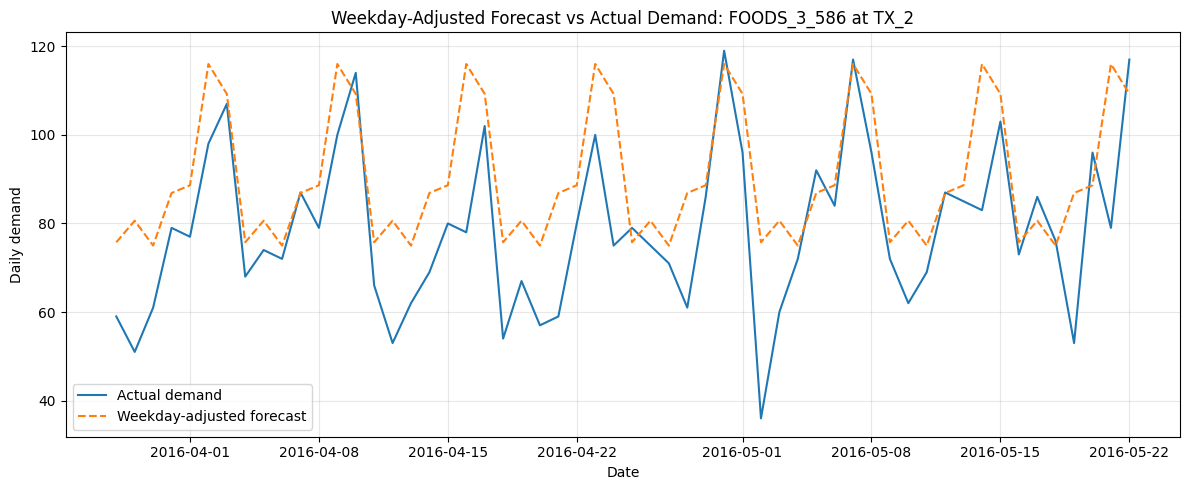

Step 18 completed: Weekday-adjusted baseline forecast created.

Recent weekday average demand used for forecasting:


,wday,weekday,weekday_forecast,number_of_days
0,1,Saturday,116.000,8
1,2,Sunday,109.250,8
2,3,Monday,75.750,8
3,4,Tuesday,80.625,8
4,5,Wednesday,75.000,8
5,6,Thursday,86.875,8
6,7,Friday,88.625,8



Updated baseline forecast metrics:


,model,forecast_horizon_days,forecast_value,MAE,RMSE,MAPE_percent
0,Naive forecast,56,100.000000,24.017857,27.959473,36.776469
1,7-day moving average forecast,56,85.857143,16.252551,19.549845,23.896987
2,28-day moving average forecast,56,87.714286,17.089286,20.293950,25.387442
3,Weekday-adjusted moving average forecast,56,75.750000,12.888393,16.855412,19.438206



Updated forecast results preview:


,date,actual_demand,naive_forecast,ma_7_forecast,ma_28_forecast,wday,weekday,weekday_adjusted_forecast
0,2016-03-28,59,100,85.857143,87.714286,3,Monday,75.750
1,2016-03-29,51,100,85.857143,87.714286,4,Tuesday,80.625
2,2016-03-30,61,100,85.857143,87.714286,5,Wednesday,75.000
3,2016-03-31,79,100,85.857143,87.714286,6,Thursday,86.875
4,2016-04-01,77,100,85.857143,87.714286,7,Friday,88.625
5,2016-04-02,98,100,85.857143,87.714286,1,Saturday,116.000
6,2016-04-03,107,100,85.857143,87.714286,2,Sunday,109.250
7,2016-04-04,68,100,85.857143,87.714286,3,Monday,75.750
8,2016-04-05,74,100,85.857143,87.714286,4,Tuesday,80.625
9,2016-04-06,72,100,85.857143,87.714286,5,Wednesday,75.000



Validation checks:
Missing weekday-adjusted forecasts: 0
Forecast results shape: (56, 8)

Tables saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/weekday_adjusted_forecast_results_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/updated_baseline_forecast_metrics_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/recent_weekday_average_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/weekday_adjusted_forecast_vs_actual_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/weekday_adjusted_forecast_vs_actual_FOODS_3_586_TX_2.pdf


In [ ]:
# Step 18: Build a weekday-adjusted baseline forecast

# Define the recent training window
recent_window_days = 56

# Use the most recent 56 days of training data to estimate weekday-level demand
recent_train_data = train_data.tail(recent_window_days).copy()

# Calculate recent average demand by weekday
recent_weekday_average = recent_train_data.groupby(
    ["wday", "weekday"], as_index=False
).agg(
    weekday_forecast=("demand", "mean"),
    number_of_days=("demand", "count")
)

# Add weekday columns from test_data to forecast_results if they are not already included
forecast_results = forecast_results.copy()

if "wday" not in forecast_results.columns:
    forecast_results = forecast_results.merge(
        test_data[["date", "wday", "weekday"]],
        on="date",
        how="left"
    )

# Remove old weekday-adjusted forecast column if this cell is re-run
if "weekday_adjusted_forecast" in forecast_results.columns:
    forecast_results = forecast_results.drop(columns=["weekday_adjusted_forecast"])

# Add weekday-adjusted forecast to forecast results
forecast_results = forecast_results.merge(
    recent_weekday_average[["wday", "weekday_forecast"]],
    on="wday",
    how="left"
)

forecast_results = forecast_results.rename(
    columns={"weekday_forecast": "weekday_adjusted_forecast"}
)

# Calculate metrics for weekday-adjusted forecast
actual = forecast_results["actual_demand"]

weekday_adjusted_metrics = calculate_forecast_metrics(
    actual_values=actual,
    predicted_values=forecast_results["weekday_adjusted_forecast"],
    model_name="Weekday-adjusted moving average forecast",
    forecast_horizon_days=forecast_horizon
)

# Remove old weekday-adjusted metrics if this cell is re-run
baseline_metrics = baseline_metrics[
    baseline_metrics["model"] != "Weekday-adjusted moving average forecast"
].copy()

# Combine all baseline metrics
baseline_metrics = pd.concat(
    [
        baseline_metrics,
        pd.DataFrame([weekday_adjusted_metrics])
    ],
    ignore_index=True
)

# Save updated forecast results and metrics
weekday_forecast_results_path = tables_dir / "weekday_adjusted_forecast_results_FOODS_3_586_TX_2.csv"
updated_baseline_metrics_path = tables_dir / "updated_baseline_forecast_metrics_FOODS_3_586_TX_2.csv"
recent_weekday_average_path = tables_dir / "recent_weekday_average_FOODS_3_586_TX_2.csv"

forecast_results.to_csv(weekday_forecast_results_path, index=False)
baseline_metrics.to_csv(updated_baseline_metrics_path, index=False)
recent_weekday_average.to_csv(recent_weekday_average_path, index=False)


# ============================================================
# Plot: Actual demand vs weekday-adjusted forecast
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    forecast_results["date"],
    forecast_results["actual_demand"],
    linewidth=1.5,
    label="Actual demand"
)

plt.plot(
    forecast_results["date"],
    forecast_results["weekday_adjusted_forecast"],
    linewidth=1.5,
    linestyle="--",
    label="Weekday-adjusted forecast"
)

plt.title("Weekday-Adjusted Forecast vs Actual Demand: FOODS_3_586 at TX_2")
plt.xlabel("Date")
plt.ylabel("Daily demand")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

weekday_adjusted_png_path = figures_dir / "weekday_adjusted_forecast_vs_actual_FOODS_3_586_TX_2.png"
weekday_adjusted_pdf_path = figures_dir / "weekday_adjusted_forecast_vs_actual_FOODS_3_586_TX_2.pdf"

plt.savefig(weekday_adjusted_png_path, dpi=300, bbox_inches="tight")
plt.savefig(weekday_adjusted_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 18 completed: Weekday-adjusted baseline forecast created.")

print("\nRecent weekday average demand used for forecasting:")
display(recent_weekday_average)

print("\nUpdated baseline forecast metrics:")
display(baseline_metrics)

print("\nUpdated forecast results preview:")
display(forecast_results.head(10))

print("\nValidation checks:")
print("Missing weekday-adjusted forecasts:", forecast_results["weekday_adjusted_forecast"].isna().sum())
print("Forecast results shape:", forecast_results.shape)

print("\nTables saved to:")
print(weekday_forecast_results_path)
print(updated_baseline_metrics_path)
print(recent_weekday_average_path)

print("\nFigures saved to:")
print(weekday_adjusted_png_path)
print(weekday_adjusted_pdf_path)

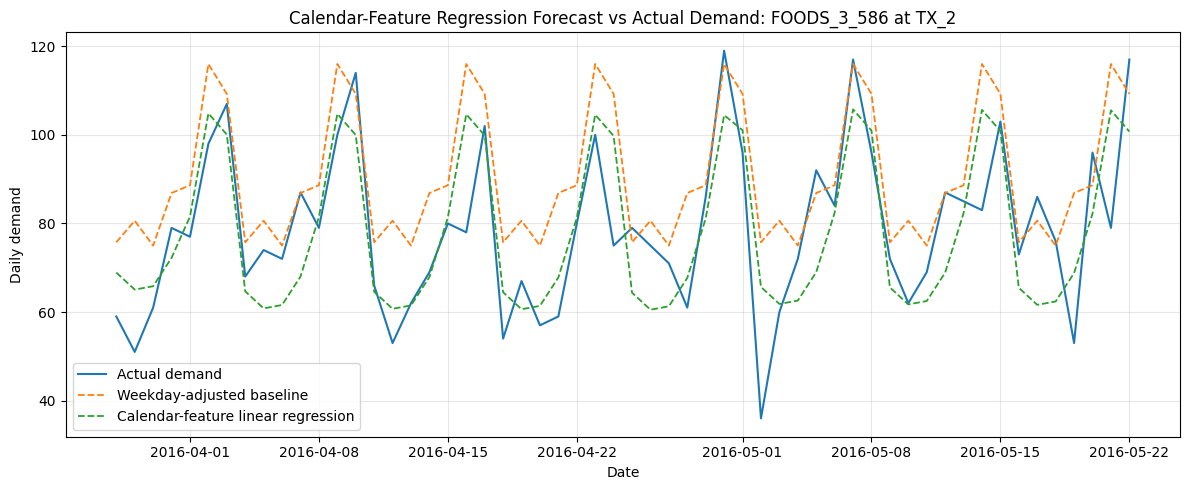

Step 19 completed: Calendar-feature linear regression forecast created.

Number of training observations:
1885

Number of testing observations:
56

Number of features used:
21

Feature columns:
['sell_price', 'time_index', 'wday_1', 'wday_2', 'wday_3', 'wday_4', 'wday_5', 'wday_6', 'wday_7', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']

Forecast model comparison metrics:


,model,forecast_horizon_days,forecast_value,MAE,RMSE,MAPE_percent
0,Calendar-feature linear regression forecast,56,68.908215,9.836198,12.450328,13.450610
1,Weekday-adjusted moving average forecast,56,75.750000,12.888393,16.855412,19.438206
2,7-day moving average forecast,56,85.857143,16.252551,19.549845,23.896987
3,28-day moving average forecast,56,87.714286,17.089286,20.293950,25.387442
4,Naive forecast,56,100.000000,24.017857,27.959473,36.776469



Forecast results preview:


,date,actual_demand,naive_forecast,ma_7_forecast,ma_28_forecast,wday,weekday,weekday_adjusted_forecast,calendar_regression_forecast
0,2016-03-28,59,100,85.857143,87.714286,3,Monday,75.750,68.908215
1,2016-03-29,51,100,85.857143,87.714286,4,Tuesday,80.625,65.065299
2,2016-03-30,61,100,85.857143,87.714286,5,Wednesday,75.000,65.832442
3,2016-03-31,79,100,85.857143,87.714286,6,Thursday,86.875,72.246204
4,2016-04-01,77,100,85.857143,87.714286,7,Friday,88.625,81.545925
5,2016-04-02,98,100,85.857143,87.714286,1,Saturday,116.000,104.854560
6,2016-04-03,107,100,85.857143,87.714286,2,Sunday,109.250,100.060299
7,2016-04-04,68,100,85.857143,87.714286,3,Monday,75.750,64.668941
8,2016-04-05,74,100,85.857143,87.714286,4,Tuesday,80.625,60.826026
9,2016-04-06,72,100,85.857143,87.714286,5,Wednesday,75.000,61.593168



Validation checks:
Missing regression forecasts: 0
Minimum regression forecast: 60.525779640217664
Maximum regression forecast: 105.75119843135485

Tables saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/calendar_regression_forecast_results_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/forecast_model_comparison_metrics_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/calendar_regression_forecast_vs_actual_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/calendar_regression_forecast_vs_actual_FOODS_3_586_TX_2.pdf


In [ ]:
# Step 19: Build a calendar-feature linear regression forecast

from sklearn.linear_model import LinearRegression

# Define a reusable forecast evaluation function
# This is included again to make the notebook more robust if the kernel is restarted.
def calculate_forecast_metrics(actual_values, predicted_values, model_name, forecast_horizon_days):
    actual_values = pd.Series(actual_values).reset_index(drop=True)
    predicted_values = pd.Series(predicted_values).reset_index(drop=True)
    
    mae = np.mean(np.abs(actual_values - predicted_values))
    rmse = np.sqrt(np.mean((actual_values - predicted_values) ** 2))
    
    nonzero_mask = actual_values != 0
    mape = np.mean(
        np.abs((actual_values[nonzero_mask] - predicted_values[nonzero_mask]) / actual_values[nonzero_mask])
    ) * 100
    
    return {
        "model": model_name,
        "forecast_horizon_days": forecast_horizon_days,
        "forecast_value": predicted_values.iloc[0],
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_percent": mape
    }


# Create forecasting features
def create_calendar_features(df, start_date):
    feature_df = df.copy()
    
    # Create a time trend variable
    feature_df["time_index"] = (feature_df["date"] - start_date).dt.days
    
    # Create dummy variables for weekday and month
    weekday_dummies = pd.get_dummies(
        feature_df["wday"],
        prefix="wday",
        dtype=int
    )
    
    month_dummies = pd.get_dummies(
        feature_df["month"],
        prefix="month",
        dtype=int
    )
    
    # Combine numeric and dummy features
    X = pd.concat(
        [
            feature_df[["sell_price", "time_index"]],
            weekday_dummies,
            month_dummies
        ],
        axis=1
    )
    
    y = feature_df["demand"]
    
    return X, y


# Define the start date for time index calculation
start_date = daily_demand["date"].min()

# Create training and testing feature matrices
X_train, y_train = create_calendar_features(train_data, start_date)
X_test, y_test = create_calendar_features(test_data, start_date)

# Make sure test features have exactly the same columns as training features
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Fit the linear regression model
calendar_regression_model = LinearRegression()
calendar_regression_model.fit(X_train, y_train)

# Generate test-period forecasts
calendar_regression_forecast = calendar_regression_model.predict(X_test)

# Demand cannot be negative, so clip negative forecasts to zero
calendar_regression_forecast = pd.Series(
    calendar_regression_forecast,
    index=forecast_results.index
).clip(lower=0)

# Add regression forecast to forecast results
forecast_results = forecast_results.copy()

if "calendar_regression_forecast" in forecast_results.columns:
    forecast_results = forecast_results.drop(columns=["calendar_regression_forecast"])

forecast_results["calendar_regression_forecast"] = calendar_regression_forecast

# Calculate model metrics
calendar_regression_metrics = calculate_forecast_metrics(
    actual_values=forecast_results["actual_demand"],
    predicted_values=forecast_results["calendar_regression_forecast"],
    model_name="Calendar-feature linear regression forecast",
    forecast_horizon_days=forecast_horizon
)

# Combine with existing baseline metrics
forecast_model_comparison_metrics = baseline_metrics[
    baseline_metrics["model"] != "Calendar-feature linear regression forecast"
].copy()

forecast_model_comparison_metrics = pd.concat(
    [
        forecast_model_comparison_metrics,
        pd.DataFrame([calendar_regression_metrics])
    ],
    ignore_index=True
)

forecast_model_comparison_metrics = forecast_model_comparison_metrics.sort_values(
    "MAE"
).reset_index(drop=True)

# Save forecast results and model comparison metrics
calendar_regression_results_path = tables_dir / "calendar_regression_forecast_results_FOODS_3_586_TX_2.csv"
forecast_model_comparison_metrics_path = tables_dir / "forecast_model_comparison_metrics_FOODS_3_586_TX_2.csv"

forecast_results.to_csv(calendar_regression_results_path, index=False)
forecast_model_comparison_metrics.to_csv(forecast_model_comparison_metrics_path, index=False)


# ============================================================
# Plot: Actual demand vs best baseline and regression forecast
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    forecast_results["date"],
    forecast_results["actual_demand"],
    linewidth=1.5,
    label="Actual demand"
)

plt.plot(
    forecast_results["date"],
    forecast_results["weekday_adjusted_forecast"],
    linewidth=1.3,
    linestyle="--",
    label="Weekday-adjusted baseline"
)

plt.plot(
    forecast_results["date"],
    forecast_results["calendar_regression_forecast"],
    linewidth=1.3,
    linestyle="--",
    label="Calendar-feature linear regression"
)

plt.title("Calendar-Feature Regression Forecast vs Actual Demand: FOODS_3_586 at TX_2")
plt.xlabel("Date")
plt.ylabel("Daily demand")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

calendar_regression_png_path = figures_dir / "calendar_regression_forecast_vs_actual_FOODS_3_586_TX_2.png"
calendar_regression_pdf_path = figures_dir / "calendar_regression_forecast_vs_actual_FOODS_3_586_TX_2.pdf"

plt.savefig(calendar_regression_png_path, dpi=300, bbox_inches="tight")
plt.savefig(calendar_regression_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 19 completed: Calendar-feature linear regression forecast created.")

print("\nNumber of training observations:")
print(len(X_train))

print("\nNumber of testing observations:")
print(len(X_test))

print("\nNumber of features used:")
print(X_train.shape[1])

print("\nFeature columns:")
print(X_train.columns.tolist())

print("\nForecast model comparison metrics:")
display(forecast_model_comparison_metrics)

print("\nForecast results preview:")
display(forecast_results.head(10))

print("\nValidation checks:")
print("Missing regression forecasts:", forecast_results["calendar_regression_forecast"].isna().sum())
print("Minimum regression forecast:", forecast_results["calendar_regression_forecast"].min())
print("Maximum regression forecast:", forecast_results["calendar_regression_forecast"].max())

print("\nTables saved to:")
print(calendar_regression_results_path)
print(forecast_model_comparison_metrics_path)

print("\nFigures saved to:")
print(calendar_regression_png_path)
print(calendar_regression_pdf_path)

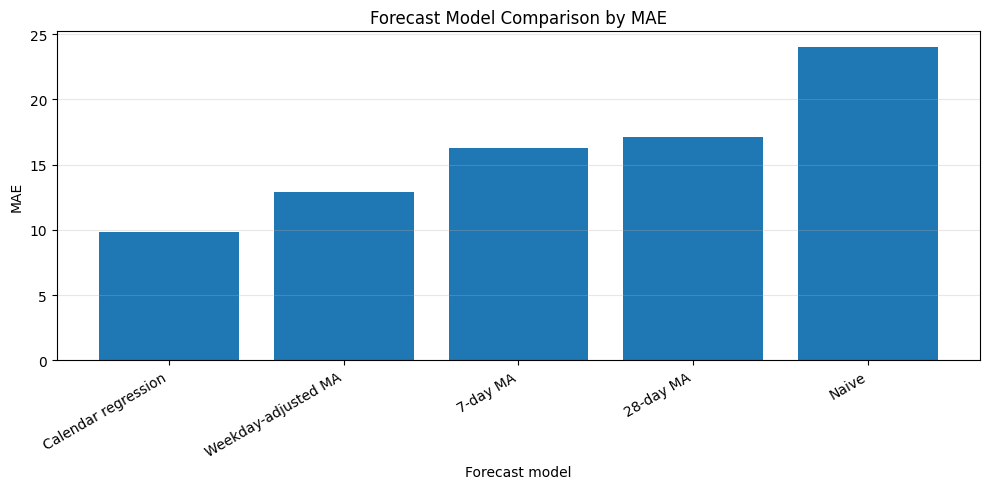

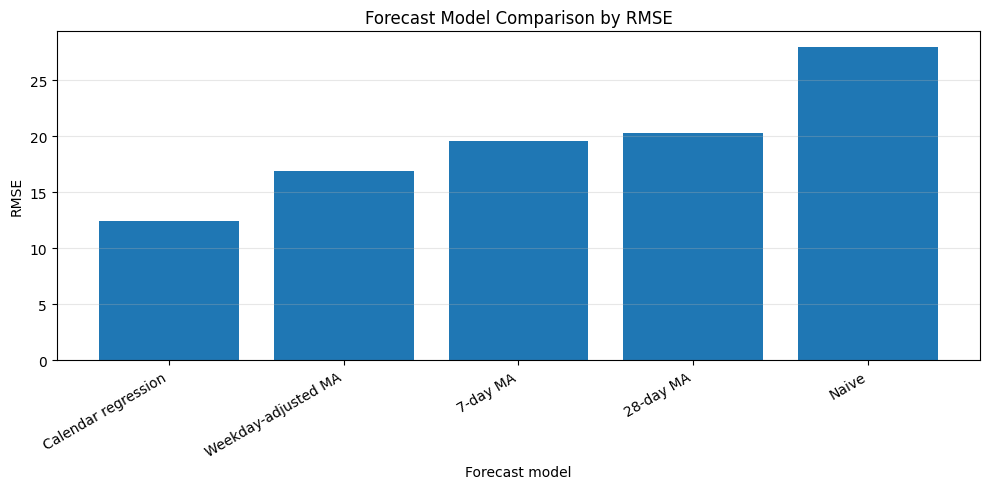

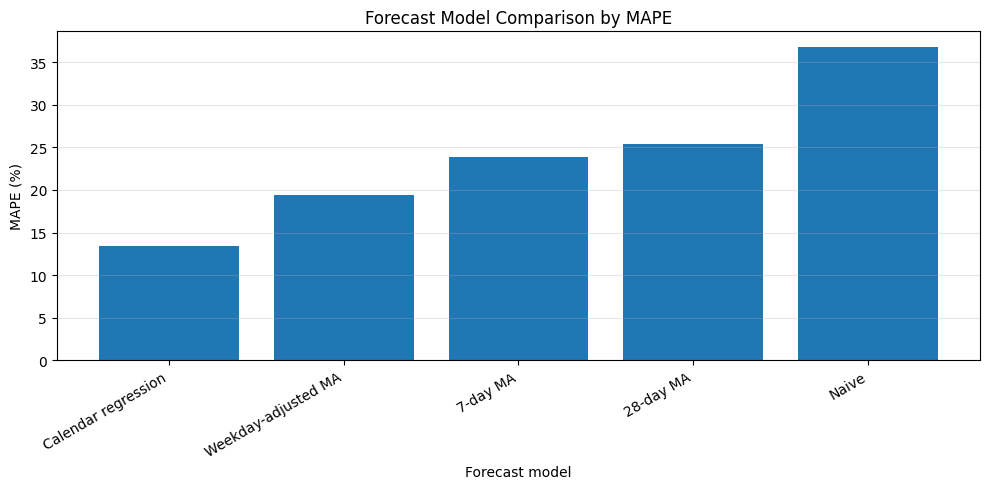

Step 20 completed: Final model comparison figures created and best forecast selected.

Final model comparison metrics:


,model,forecast_horizon_days,forecast_value,MAE,RMSE,MAPE_percent,model_short
0,Calendar-feature linear regression forecast,56,68.908215,9.836198,12.450328,13.450610,Calendar regression
1,Weekday-adjusted moving average forecast,56,75.750000,12.888393,16.855412,19.438206,Weekday-adjusted MA
2,7-day moving average forecast,56,85.857143,16.252551,19.549845,23.896987,7-day MA
3,28-day moving average forecast,56,87.714286,17.089286,20.293950,25.387442,28-day MA
4,Naive forecast,56,100.000000,24.017857,27.959473,36.776469,Naive



Best model based on MAE:
Calendar-feature linear regression forecast

Best forecast column:
calendar_regression_forecast

Selected forecast preview:


,date,actual_demand,selected_forecast,forecast_error,absolute_error
0,2016-03-28,59,68.908215,-9.908215,9.908215
1,2016-03-29,51,65.065299,-14.065299,14.065299
2,2016-03-30,61,65.832442,-4.832442,4.832442
3,2016-03-31,79,72.246204,6.753796,6.753796
4,2016-04-01,77,81.545925,-4.545925,4.545925
5,2016-04-02,98,104.854560,-6.854560,6.854560
6,2016-04-03,107,100.060299,6.939701,6.939701
7,2016-04-04,68,64.668941,3.331059,3.331059
8,2016-04-05,74,60.826026,13.173974,13.173974
9,2016-04-06,72,61.593168,10.406832,10.406832



Selected forecast summary:


,actual_demand,selected_forecast,forecast_error,absolute_error
count,56.000000,56.000000,56.000000,56.000000
mean,78.803571,77.916521,0.887051,9.836198
std,18.398043,17.095043,12.531076,7.701891
min,36.000000,60.525780,-29.665661,0.277336
25%,66.750000,63.923993,-4.981958,4.507695
50%,77.500000,68.853527,1.494289,7.237102
75%,88.250000,99.885156,9.882016,14.167530
max,119.000000,105.751198,24.377418,29.665661



Tables saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/final_model_comparison_metrics_FOODS_3_586_TX_2.csv
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/tables/selected_forecast_for_inventory_FOODS_3_586_TX_2.csv

Figures saved to:
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/forecast_model_comparison_MAE_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/forecast_model_comparison_MAE_FOODS_3_586_TX_2.pdf
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/forecast_model_comparison_RMSE_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/forecast_model_comparison_RMSE_FOODS_3_586_TX_2.pdf
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/forecast_model_comparison_MAPE_FOODS_3_586_TX_2.png
/Users/mac/Desktop/portfolio1_demand_inventory/outputs/figures/forecast_model_comparison_MAPE_FOODS_3_586_TX_2.pdf


In [ ]:
# Step 20: Create final model comparison figures and select best forecast

# Create a clean copy of model comparison metrics
final_model_comparison = forecast_model_comparison_metrics.copy()

# Add shorter model names for plotting
model_name_mapping = {
    "Calendar-feature linear regression forecast": "Calendar regression",
    "Weekday-adjusted moving average forecast": "Weekday-adjusted MA",
    "7-day moving average forecast": "7-day MA",
    "28-day moving average forecast": "28-day MA",
    "Naive forecast": "Naive"
}

final_model_comparison["model_short"] = final_model_comparison["model"].map(model_name_mapping)

# Sort models by MAE
final_model_comparison = final_model_comparison.sort_values("MAE").reset_index(drop=True)

# Identify the best model based on MAE
best_model_row = final_model_comparison.iloc[0]
best_model_name = best_model_row["model"]

# Define which forecast column corresponds to the best model
forecast_column_mapping = {
    "Calendar-feature linear regression forecast": "calendar_regression_forecast",
    "Weekday-adjusted moving average forecast": "weekday_adjusted_forecast",
    "7-day moving average forecast": "ma_7_forecast",
    "28-day moving average forecast": "ma_28_forecast",
    "Naive forecast": "naive_forecast"
}

best_forecast_column = forecast_column_mapping[best_model_name]

# Create selected forecast table for later inventory policy simulation
selected_forecast = forecast_results[
    ["date", "actual_demand", best_forecast_column]
].copy()

selected_forecast = selected_forecast.rename(
    columns={best_forecast_column: "selected_forecast"}
)

selected_forecast["forecast_error"] = (
    selected_forecast["actual_demand"] - selected_forecast["selected_forecast"]
)

selected_forecast["absolute_error"] = selected_forecast["forecast_error"].abs()

# Save final model comparison and selected forecast
final_model_comparison_path = tables_dir / "final_model_comparison_metrics_FOODS_3_586_TX_2.csv"
selected_forecast_path = tables_dir / "selected_forecast_for_inventory_FOODS_3_586_TX_2.csv"

final_model_comparison.to_csv(final_model_comparison_path, index=False)
selected_forecast.to_csv(selected_forecast_path, index=False)


# ============================================================
# Plot 1: MAE comparison
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    final_model_comparison["model_short"],
    final_model_comparison["MAE"]
)

plt.title("Forecast Model Comparison by MAE")
plt.xlabel("Forecast model")
plt.ylabel("MAE")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

mae_comparison_png_path = figures_dir / "forecast_model_comparison_MAE_FOODS_3_586_TX_2.png"
mae_comparison_pdf_path = figures_dir / "forecast_model_comparison_MAE_FOODS_3_586_TX_2.pdf"

plt.savefig(mae_comparison_png_path, dpi=300, bbox_inches="tight")
plt.savefig(mae_comparison_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Plot 2: RMSE comparison
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    final_model_comparison["model_short"],
    final_model_comparison["RMSE"]
)

plt.title("Forecast Model Comparison by RMSE")
plt.xlabel("Forecast model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

rmse_comparison_png_path = figures_dir / "forecast_model_comparison_RMSE_FOODS_3_586_TX_2.png"
rmse_comparison_pdf_path = figures_dir / "forecast_model_comparison_RMSE_FOODS_3_586_TX_2.pdf"

plt.savefig(rmse_comparison_png_path, dpi=300, bbox_inches="tight")
plt.savefig(rmse_comparison_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Plot 3: MAPE comparison
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    final_model_comparison["model_short"],
    final_model_comparison["MAPE_percent"]
)

plt.title("Forecast Model Comparison by MAPE")
plt.xlabel("Forecast model")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

mape_comparison_png_path = figures_dir / "forecast_model_comparison_MAPE_FOODS_3_586_TX_2.png"
mape_comparison_pdf_path = figures_dir / "forecast_model_comparison_MAPE_FOODS_3_586_TX_2.pdf"

plt.savefig(mape_comparison_png_path, dpi=300, bbox_inches="tight")
plt.savefig(mape_comparison_pdf_path, bbox_inches="tight")

plt.show()


# ============================================================
# Print summary outputs
# ============================================================

print("Step 20 completed: Final model comparison figures created and best forecast selected.")

print("\nFinal model comparison metrics:")
display(final_model_comparison)

print("\nBest model based on MAE:")
print(best_model_name)

print("\nBest forecast column:")
print(best_forecast_column)

print("\nSelected forecast preview:")
display(selected_forecast.head(10))

print("\nSelected forecast summary:")
display(selected_forecast[["actual_demand", "selected_forecast", "forecast_error", "absolute_error"]].describe())

print("\nTables saved to:")
print(final_model_comparison_path)
print(selected_forecast_path)

print("\nFigures saved to:")
print(mae_comparison_png_path)
print(mae_comparison_pdf_path)
print(rmse_comparison_png_path)
print(rmse_comparison_pdf_path)
print(mape_comparison_png_path)
print(mape_comparison_pdf_path)